Python jupyter notebook for LAB 0 of matrix and tensor tech for ds

In [1]:
# imports
import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt

In [13]:
# Ex 1.1
rng = np.random.default_rng()
x = rng.random(10)
x[1] = 0
print(x)
print(len(x))
print(np.count_nonzero(x))

[0.66033143 0.         0.00547343 0.88176324 0.8605122  0.07879227
 0.86636884 0.16500571 0.27657912 0.29690099]
10
9


In [21]:
n = 3
m = 4
a = rng.random((n, m))
b = rng.random((n, m))

print(a)
print(b)

a_t = a.T
print(a_t)

frobenius = np.trace(a_t @ b)
a_vector_t = a.flatten(order="F").T
b_vector = b.flatten(order="F")
print(frobenius)
print(a_vector_t @ b_vector)
print(np.isclose(frobenius, a_vector_t @ b_vector)) #True


[[0.60091741 0.25453748 0.26117309 0.38152678]
 [0.08182336 0.96618514 0.20921816 0.43985153]
 [0.73789557 0.35925566 0.79655482 0.07662456]]
[[0.20759342 0.83644353 0.30005725 0.48562252]
 [0.24198364 0.19965935 0.60676233 0.19282079]
 [0.91807376 0.57465322 0.05216006 0.56626279]]
[[0.60091741 0.08182336 0.73789557]
 [0.25453748 0.96618514 0.35925566]
 [0.26117309 0.20921816 0.79655482]
 [0.38152678 0.43985153 0.07662456]]
1.994591591153974
1.994591591153974
True


In [ ]:
x = rng.random(n**2)
y = rng.random(n**2)
x_T_y = x.T @ y
#x_T_y

caps_X = x.reshape(n, n, order="F")
caps_Y = y.reshape(n, n, order="F")

print(np.isclose(x_T_y, np.trace(caps_X.T @ caps_Y))) #True

True


In [ ]:
# Ex 2
B = rng.random((m, n))
B_star = B.T #since are all Real numbers we can use the transpose instead of the conjugate transpose
b_star_b = B_star @ B
print(np.linalg.eigvalsh(b_star_b))
np.linalg.matrix_rank(B)
C = np.array([
    [1.0, 1.0, 2.0],
    [3.0, 3.0, 4.0],
    [5.0, 5.0, 6.0],
    [7.0, 7.0, 8.0]
])
np.linalg.matrix_rank(C)
c_star_c = C.T @ C
c_eigenvalues = np.linalg.eigvalsh(c_star_c)
print(np.isclose(c_eigenvalues[0], 0)) # is positive semidefinite

[0.06288443 0.20930874 5.29384313]
True


Full SVD times: [0.004545083000266459, 0.006697250006254762, 0.007776457998261321, 0.00933558299584547, 0.009012042006361298, 0.008531166997272521, 0.010608875003526919, 0.011835332996270154, 0.013153583997336682, 0.013338249998923857, 0.015174166997894645, 0.017771416998584755, 0.014074040998821147, 0.015475665997655597, 0.01716916699660942, 0.018517666998377535, 0.01778733300307067, 0.01894775000255322, 0.019263791997218505, 0.017752499996277038, 0.01880900000105612, 0.02100929200241808, 0.018898457994509954, 0.020243124999979045, 0.021947958004602697, 0.020094541003345512, 0.021569625001575332, 0.02189370900305221, 0.021018999999796506, 0.022718749998603016, 0.024832750001223758, 0.0254813749997993, 0.024762957997154444, 0.025389583002834115, 0.02708925000479212, 0.02518195800075773, 0.027482958998007234, 0.02916574999835575, 0.029077541999868117, 0.02803495900298003, 0.03153129200654803, 0.030438583002251107, 0.03118041700508911, 0.03229366699815728, 0.03285141699598171, 0.03276950

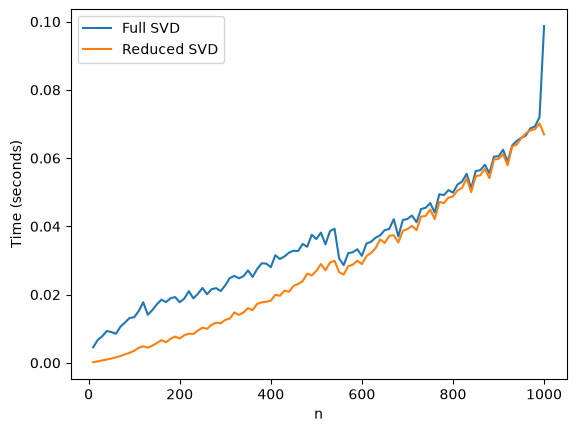

In [57]:
# Ex 3
import time
m = 1000
n = 10

n_values = []
full_times = []
reduced_times = []

for current_n in range(n, m + 1, 10):
    A = rng.random((m, current_n))

    full_svd_start = time.perf_counter()
    np.linalg.svd(A, full_matrices=True)
    full_svd_end = time.perf_counter()
    full_svd_elapsed = full_svd_end - full_svd_start

    reduced_svd_start = time.perf_counter()
    np.linalg.svd(A, full_matrices=False)
    reduced_svd_end = time.perf_counter()
    reduced_svd_elapsed = reduced_svd_end - reduced_svd_start

    full_times.append(full_svd_elapsed)
    reduced_times.append(reduced_svd_elapsed)
    n_values.append(current_n)

print("Full SVD times:", full_times)
print("Reduced SVD times:", reduced_times)

plt.plot(n_values, full_times, label="Full SVD")
plt.plot(n_values, reduced_times, label="Reduced SVD")

plt.xlabel("n")
plt.ylabel("Time (seconds)")
plt.legend()
plt.show()

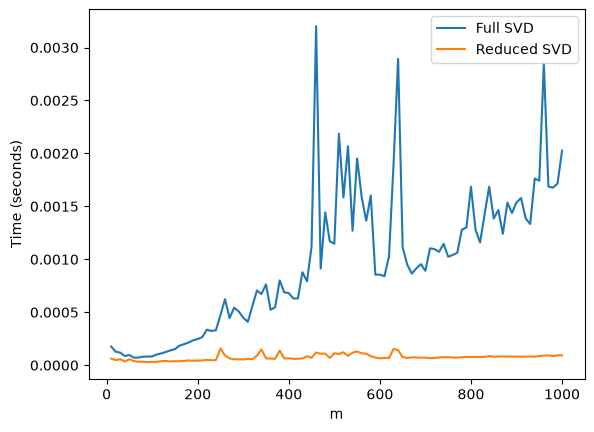

In [61]:
# Ex 3.2
n = 10
max_m = 1000

m_values = []
full_times = []
reduced_times = []

for current_m in range(n, max_m + 1, 10):
    A = rng.random((current_m, n))

    full_svd_start = time.perf_counter()
    np.linalg.svd(A, full_matrices=True)
    full_svd_end = time.perf_counter()

    reduced_svd_start = time.perf_counter()
    np.linalg.svd(A, full_matrices=False)
    reduced_svd_end = time.perf_counter()

    full_times.append(full_svd_end - full_svd_start)
    reduced_times.append(reduced_svd_end - reduced_svd_start)
    m_values.append(current_m)

plt.plot(m_values, full_times, label="Full SVD")
plt.plot(m_values, reduced_times, label="Reduced SVD")

plt.xlabel("m")
plt.ylabel("Time (seconds)")
plt.legend()
plt.show()

In [63]:
singular_values = np.linalg.svd(A, compute_uv=False)

eigenvalues = np.linalg.eigvalsh(A.T @ A)

eigenvalues = np.clip(eigenvalues, 0, None)

sqrt_eigenvalues = np.sqrt(eigenvalues)[::-1]

print("Singular values:",singular_values)

print("Sqrt eigenvalues of A.T @ A:", sqrt_eigenvalues)

print("Do they match?", np.allclose(singular_values, sqrt_eigenvalues))

Singular values: [51.04988883  9.78534592  9.58556091  9.38693396  9.24594779  9.07999492
  9.00637609  8.83279218  8.49672345  8.28358557]
Sqrt eigenvalues of A.T @ A: [51.04988883  9.78534592  9.58556091  9.38693396  9.24594779  9.07999492
  9.00637609  8.83279218  8.49672345  8.28358557]
Do they match? True


In [ ]:
#Ex 4

rng = np.random.default_rng(0)

def svd_pseudoinverse(A):
    U, s, Vt = np.linalg.svd(A, full_matrices=False)

    # Treat extremely small singular values as zero
    tol = 1e-12

    s_inv = np.array([
        1 / sigma if sigma > tol else 0
        for sigma in s
    ])

    Sigma_dagger = np.diag(s_inv)

    A_dagger = Vt.T @ Sigma_dagger @ U.T

    return A_dagger


A = rng.random((5, 3))

# Make A rank deficient
A[:, 2] = A[:, 1]

print("Shape:", A.shape)
print("Rank:", np.linalg.matrix_rank(A))

A_dagger = svd_pseudoinverse(A)

condition_1 = np.allclose(A @ A_dagger @ A, A)

condition_2 = np.allclose(A_dagger @ A @ A_dagger, A_dagger)

condition_3 = np.allclose((A @ A_dagger).T, A @ A_dagger)

condition_4 = np.allclose((A_dagger @ A).T, A_dagger @ A)

print(condition_1)
print(condition_2)
print(condition_3)
print(condition_4)

Shape: (5, 3)
Rank: 2
True
True
True
True


In [ ]:
#Ex 4.2

A = rng.random((5, 3))

#print("Rank:", np.linalg.matrix_rank(A))

A_dagger = np.linalg.inv(A.T @ A) @ A.T

A_dagger = svd_pseudoinverse(A)

condition_1 = np.allclose(A @ A_dagger @ A, A)

condition_2 = np.allclose(A_dagger @ A @ A_dagger, A_dagger)

condition_3 = np.allclose((A @ A_dagger).T, A @ A_dagger)

condition_4 = np.allclose((A_dagger @ A).T, A_dagger @ A)

print(condition_1)
print(condition_2)
print(condition_3)
print(condition_4)

True
True
True
True


In [ ]:
# Ex 4.3
A = rng.random((3, 5))

# Make two rows identical
A[2, :] = A[1, :]

print("Shape:", A.shape)
print("Rank:", np.linalg.matrix_rank(A))

A_dagger = svd_pseudoinverse(A)

condition_1 = np.allclose(A @ A_dagger @ A, A)

condition_2 = np.allclose(A_dagger @ A @ A_dagger, A_dagger)

condition_3 = np.allclose((A @ A_dagger).T, A @ A_dagger)

condition_4 = np.allclose((A_dagger @ A).T, A_dagger @ A)

print(condition_1)
print(condition_2)
print(condition_3)
print(condition_4)

Shape: (3, 5)
Rank: 2
True
True
True
True


In [ ]:
#Ex 4.4
A = rng.random((3, 5))

print("Rank:", np.linalg.matrix_rank(A))

A_dagger = A.T @ np.linalg.inv(A @ A.T)

condition_1 = np.allclose(A @ A_dagger @ A, A)

condition_2 = np.allclose(A_dagger @ A @ A_dagger, A_dagger)

condition_3 = np.allclose((A @ A_dagger).T, A @ A_dagger)

condition_4 = np.allclose((A_dagger @ A).T, A_dagger @ A)

print(condition_1)
print(condition_2)
print(condition_3)
print(condition_4)

Rank: 3
True
True
True
True
